# 2 — Learned deviations (without PDHG)

Learned scheme against the zero-deviation baseline and the random control, on
one held-out Mayo slice. Run `main.py` first: it trains the model and writes
the checkpoint loaded below.

Figures are saved as PDF in `plots/` (prefix `2_`).

In [1]:
import torch

from utils.experiments import (build_test_instance, reference_solution, run_fbs,
                               random_direction, objective_gap, time_table, load_model)
from utils.plots import apply_paper_style, plot_curves, show_images

apply_paper_style()

In [ ]:
# --- configuration (must match main.py) ---------------------------------------
SIZE = 128
N_ANGLES = 180
NOISE_LEVEL = 0.05
GAMMA = 2
PRIMAL_STEP = 1.5          # primal step tau (see main.py)

TEST_PATIENT = "L014"      # never used for training or validation
TEST_SLICE = 0
MAYO_CACHE_DIR = "./data/mayo_cache_128"
CKPT = "kkt_tomo_128_gamma_2_objective_alpha_04.pt"    # written by main.py
# written by main.py with USE_SAFEGUARD = False; if the file is missing, the
# ablation applies the safeguarded model without its safeguard instead
CKPT_NOSAFE = "kkt_tomo_128_gamma_2_nosafe_objective_alpha_04.pt"

T_TRAIN = 10               # unrolling horizon used in training
T_LONG = 100               # length of the convergence curves
T_REF = 6000               # length of the run that defines F* (cached in results/)

In [3]:
inst = build_test_instance(SIZE, N_ANGLES, NOISE_LEVEL, GAMMA, TEST_PATIENT, TEST_SLICE,
                           MAYO_CACHE_DIR, primal_step=PRIMAL_STEP)
ref = reference_solution(inst, T_REF)
print(f"F* = {ref['f_star']:.4f}, PSNR of the TGV2 solution = {ref['psnr']:.2f} dB")

F* = 0.6605, PSNR of the TGV2 solution = 26.81 dB


In [4]:
import os

model, ckpt = load_model(CKPT, inst, T=T_TRAIN)
model_nosafe = (load_model(CKPT_NOSAFE, inst, T=T_TRAIN, use_safeguard=False)[0]
                if os.path.exists(CKPT_NOSAFE) else model)

## Training curves

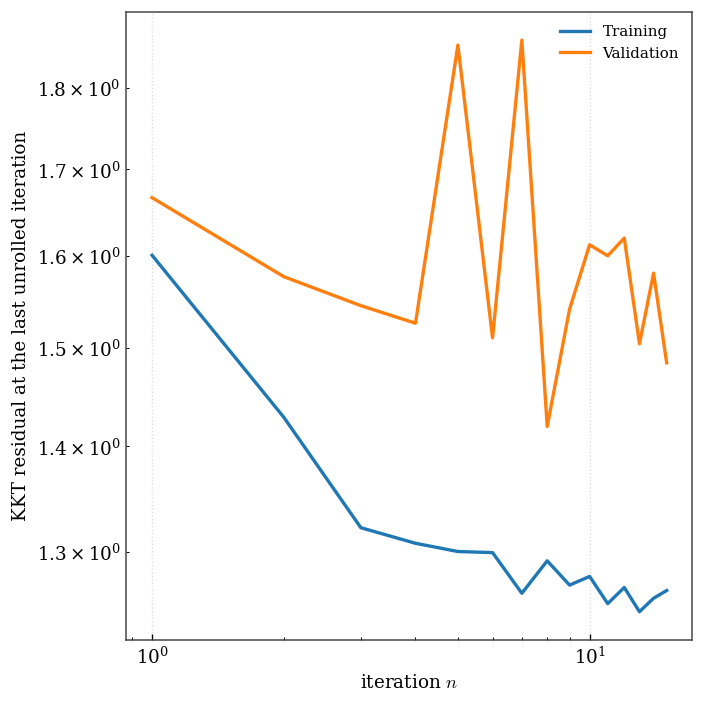

In [5]:
plot_curves({"Training": ckpt["train_loss_history"], "Validation": ckpt["val_loss_history"]},
            "KKT residual at the last unrolled iteration", "2_training", show=True)

## Runs

In [6]:
results = {
    "Zero deviation": run_fbs(inst, T_LONG, snapshots=(T_TRAIN,)),
    "Learned": run_fbs(inst, T_LONG, model, snapshots=(T_TRAIN,)),
    "Random": run_fbs(inst, T_LONG, random_direction(seed=0), snapshots=(T_TRAIN,)),
}
no_safeguard = run_fbs(inst, T_LONG, model_nosafe, use_safeguard=False, snapshots=(T_TRAIN,))

## Convergence

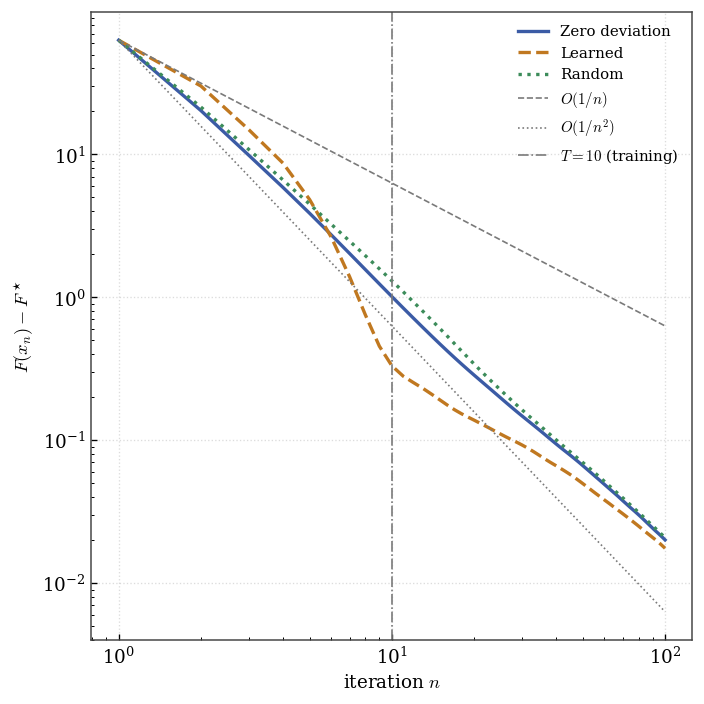

In [7]:
gaps = {label: objective_gap(r, ref["f_star"]) for label, r in results.items()}
plot_curves(gaps, r"$F(x_n) - F^\star$", "2_objective_gap", slopes=True, horizon=T_TRAIN, show=True)

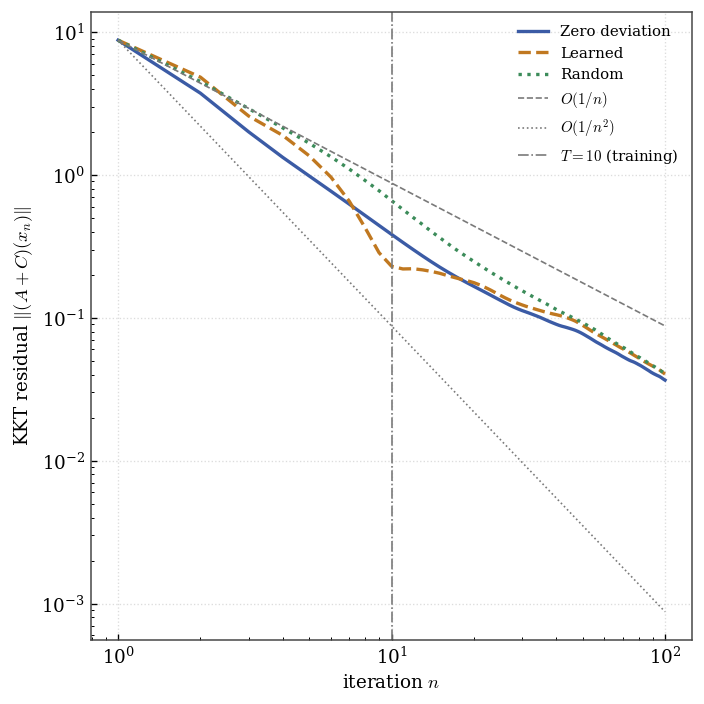

In [8]:
plot_curves({label: r["kkt"] for label, r in results.items() if "kkt" in r},
            r"KKT residual $\|(A + C)(x_n)\|$", "2_kkt", slopes=True, horizon=T_TRAIN, show=True)

## Safeguard ablation

The same trained network, with its output applied directly instead of being rescaled by the safeguard.

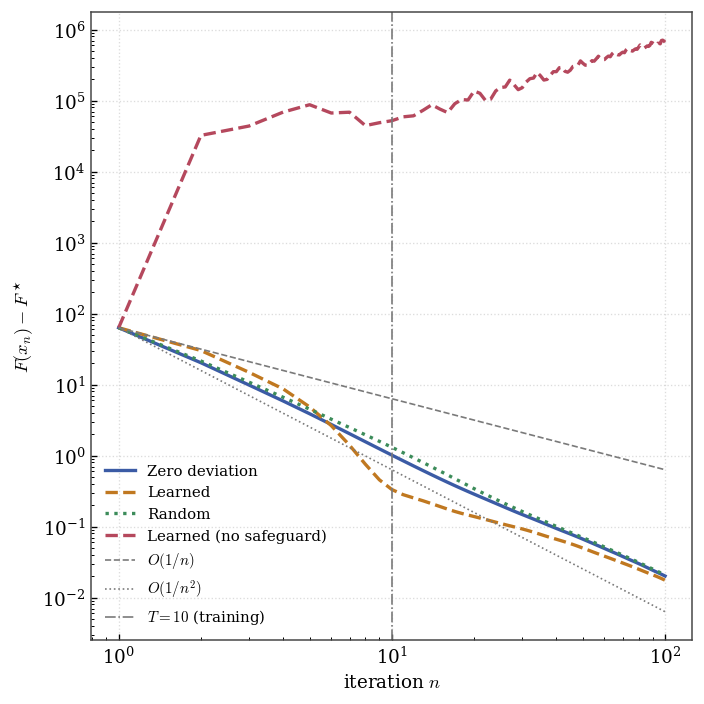

In [9]:
ablation = dict(results, **{"Learned (no safeguard)": no_safeguard})
plot_curves({label: objective_gap(r, ref["f_star"]) for label, r in ablation.items()},
            r"$F(x_n) - F^\star$", "2_safeguard_ablation", slopes=True, horizon=T_TRAIN, show=True)

## PSNR

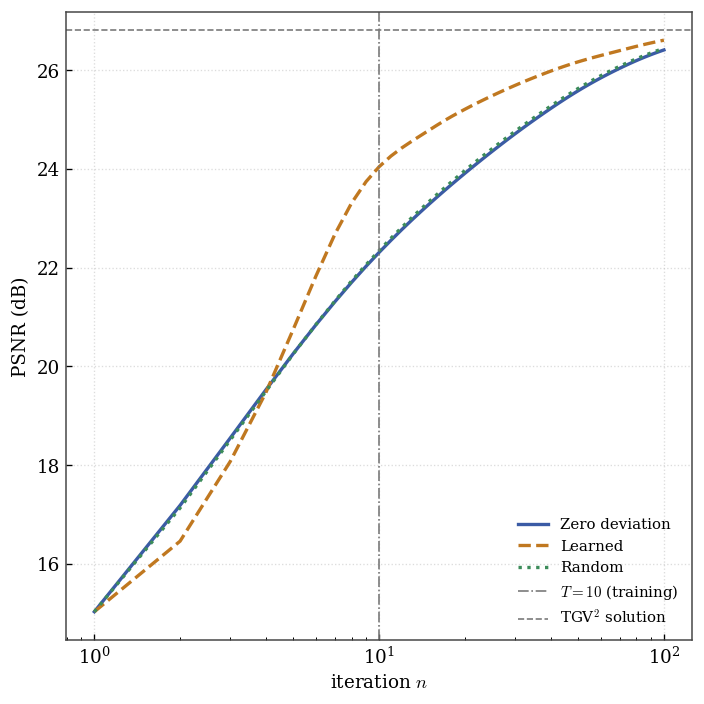

In [10]:
plot_curves({label: r["psnr"] for label, r in results.items()}, "PSNR (dB)", "2_psnr",
            loglog=False, horizon=T_TRAIN, hline=(ref["psnr"], r"TGV$^2$ solution"), show=True)

## Reconstructions

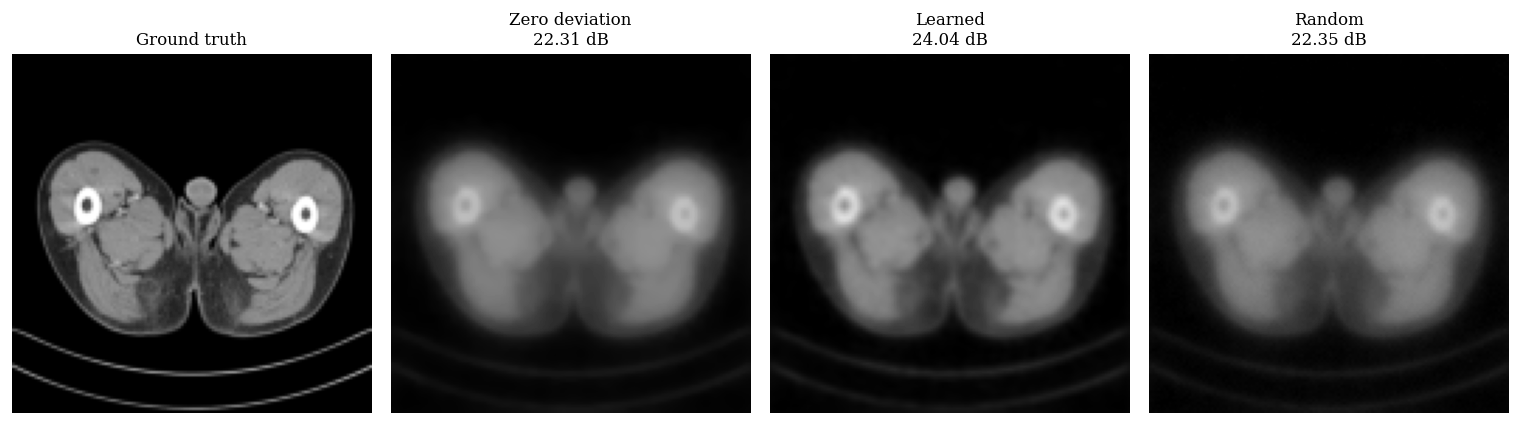

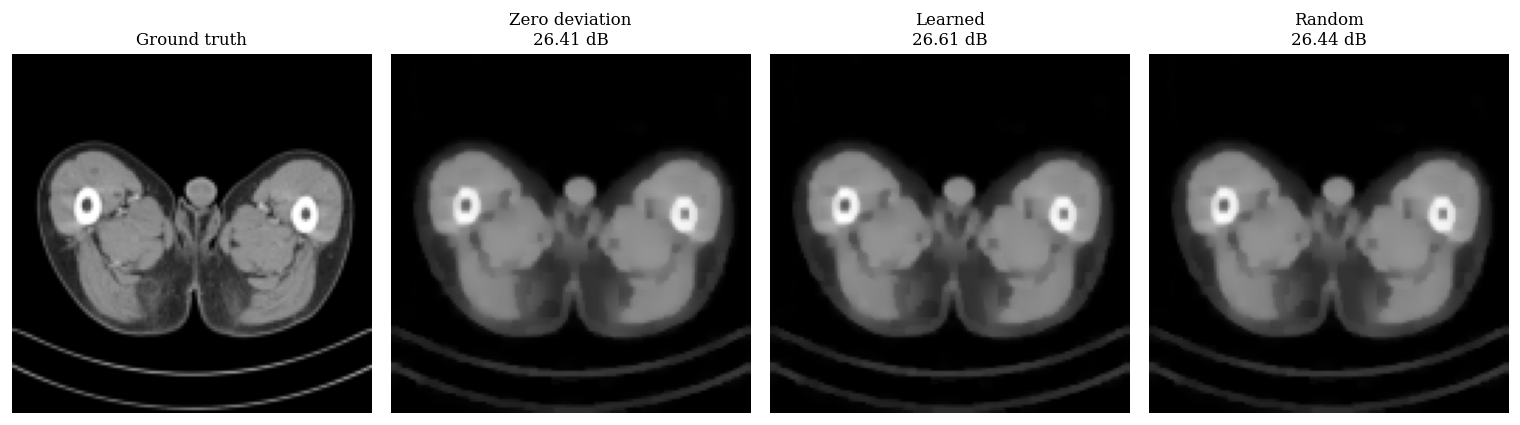

In [11]:
def gallery(n):
    """Ground truth and the reconstruction of every method after n iterations."""
    images = {"Ground truth": inst["clean"]}
    for label, r in results.items():
        images[f"{label}\n{r['psnr'][n - 1]:.2f} dB"] = r["images"][n]
    return images

show_images(gallery(T_TRAIN), "2_reconstructions_{}_iterations".format(T_TRAIN), show=True)
show_images(gallery(T_LONG), "2_reconstructions_{}_iterations".format(T_LONG), show=True)

## Time comparison

Time per iteration is measured on a separate short run without any monitoring
(no KKT residual, objective or PSNR computed). The table is also written as
LaTeX in `plots/`.

In [12]:
time_table(results, name="2_time_comparison")

,Time / iteration (ms),PSNR after 10 it. (dB)
Method,,
Zero deviation,6,22.31
Learned,19,24.04
Random,18,22.35
